# Trojan Detection Using Machine Learning

Comparing different algorithms to see which works best for detecting trojans in network traffic.

Dataset: 177,482 network traffic samples from Kaggle

GitHub: https://github.com/harvey1076/CMP7239-Trojan-Detection-

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, Flatten, MaxPooling1D

import warnings
warnings.filterwarnings('ignore')

## Data Preprocessing

Before training any models, I need to clean the dataset properly. The raw data has issues that would confuse the algorithms if I don't fix them first.

**What I'm doing and why:**

**1. Removing metadata columns**

Columns like IP addresses, timestamps, and port numbers would let the model cheat. For example, if the training data has IP 192.168.1.50 labeled as "trojan", the model might just memorize "this IP = trojan" instead of learning actual attack patterns. In real deployment, trojans come from new IPs we've never seen.

I need the model to learn behavioral patterns in the network traffic itself - things like packet sizes, flow durations, byte rates. These patterns would appear regardless of which IP the trojan uses.

**2. Handling missing values**

Some samples have missing data. Rather than delete those samples (wasting data), I'm filling gaps with the median value of each column. Using median instead of average because network traffic has outliers - like one massive packet of 999999 bytes. The median ignores these extremes better than the mean.

**3. Removing highly correlated features**

If two features give basically the same information (like "total bytes" and "bytes per second times duration"), keeping both just adds noise. The model wastes time trying to figure out which one to use when they're saying the same thing. I'm removing features that are more than 95% similar to each other.

**4. Encoding the target variable**

The dataset labels are text: "benign" or "trojan". Machine learning algorithms need numbers, so I'm converting these to 0 and 1.

**5. Splitting train/test sets**

I'm keeping 20% of the data completely separate for testing. The model never sees this during training. This way I can check if it actually learned patterns or just memorized the training data. Using stratify to make sure both sets have the same proportion of benign/trojan samples.

**6. Scaling features**

Different features have wildly different ranges. Packet size might be 0-10000, but flow duration might be 0-100. Without scaling, algorithms pay too much attention to bigger numbers just because they're bigger, not because they're more important. StandardScaler makes all features have the same scale so they're treated equally.

This is especially critical for neural networks which are very sensitive to input ranges.

In [3]:
# load the dataset
dataset_path = "/content/drive/MyDrive/Trojan_Detection.csv"
df = pd.read_csv(dataset_path)
df.columns = df.columns.str.strip()

print(f"Original dataset: {df.shape[0]} rows, {df.shape[1]} columns")

# drop metadata columns that would cause data leakage
metadata_cols = ['Unnamed: 0', 'Flow ID', 'Source IP', 'Destination IP', 'Timestamp',
                 'Source Port', 'Destination Port', 'Protocol', 'Fwd Header Length.1']
df = df.drop(columns=[c for c in metadata_cols if c in df.columns], errors='ignore')

print(f"After dropping metadata: {df.shape[1]} columns")

# replace infinite values with NaN then fill with median
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(df.median(numeric_only=True))

# encode target: benign=0, trojan=1
le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Class distribution: {y.value_counts().to_dict()}")

# remove features with >95% correlation
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
X = X.drop(columns=to_drop)

print(f"\nAfter correlation filtering: {X.shape[1]} features")
print(f"Removed {len(to_drop)} correlated features")

# 80/20 train test split with stratification
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTraining samples: {X_train_raw.shape[0]}")
print(f"Testing samples: {X_test_raw.shape[0]}")

# scale features to mean=0, std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

print(f"\nFeatures scaled with StandardScaler")

Original dataset: 177482 rows, 86 columns
After dropping metadata: 77 columns
Class distribution: {1: 90683, 0: 86799}

After correlation filtering: 56 features
Removed 20 correlated features

Training samples: 141985
Testing samples: 35497

Features scaled with StandardScaler


**Preprocessing Results:**

Looking at the output, the dataset started with 177,482 samples. After removing metadata and correlations, I'm left with 56 features (down from 85 originally).

The class distribution shows the data is fairly balanced between benign and trojan samples. This is good - if it was 95% benign and 5% trojan, a model could just guess "benign" every time and get high accuracy without learning anything useful.

Training set has about 142,000 samples (80%) and test set has about 35,000 (20%). This gives the models plenty of data to learn from while keeping enough for reliable testing.

The data is now clean and ready for the algorithms.

In [4]:
# store results from all models
results = {}
dl_histories = {}

## Understanding the Metrics

Before running the algorithms, I need to explain what the metrics mean since they'll be used to evaluate every model.

**Accuracy** = (correct predictions) / (total predictions)
- Simple overall measure: what percentage did we get right?
- For this dataset with balanced classes, accuracy is meaningful
- Example: 64% accuracy means we correctly classified 64 out of 100 samples

**Precision** = (true trojans we found) / (everything we labeled trojan)
- Answers: "When we say it's a trojan, how often are we right?"
- High precision = few false alarms
- Example: 65% precision means when we flag something as trojan, we're correct 65% of the time
- Matters because false alarms waste security analyst time

**Recall** = (true trojans we found) / (all actual trojans in the data)
- Answers: "Of all the real trojans, what percentage did we catch?"
- High recall = we're not missing threats
- Example: 65% recall means we catch 65 out of 100 trojans, but miss 35
- MOST CRITICAL for security - missing a trojan is worse than a false alarm

**F1-Score** = harmonic mean of precision and recall
- Balances both metrics into one number
- Good when you care about both false positives AND false negatives
- Ranges from 0 (worst) to 1 (perfect)

**Confusion Matrix** = table showing where model makes mistakes
- Top-left: Correctly said "benign" ✓
- Top-right: Said "trojan" but was benign (false alarm)
- Bottom-left: Said "benign" but was trojan (MISSED THREAT - dangerous)
- Bottom-right: Correctly said "trojan" ✓

For trojan detection specifically, recall is probably most important. Better to have some false alarms than to miss real trojans getting through. But too many false positives and security teams start ignoring alerts.

## Algorithm 1: Logistic Regression

**What it is:**

Logistic Regression tries to draw a boundary line (actually a curve) to separate benign traffic from trojan traffic. It looks at all the features and tries to find a mathematical formula that best divides the two classes.

**Why I'm starting with this:**

This is the simplest classification algorithm, which makes it a perfect baseline. If something this basic works well, great. If not, I know I need more complex methods. It's fast to train so good for getting quick initial results.

**What I expect for trojan detection:**

Probably won't perform amazingly because trojans likely have complex attack patterns that can't be captured by a simple line. Real trojan behavior probably involves combinations of features that interact in non-linear ways.

If accuracy is around 50% (coin flip), that confirms the problem is complex. If it's 60-70%, the patterns might be simpler than I thought.

**Code explanation:**

`max_iter=1000` - The algorithm will try up to 1000 iterations to find the best line. With 142,000 training samples and 56 features, it needs enough iterations to properly converge and find the optimal solution.

In [5]:
# create logistic regression model
lr_model = LogisticRegression(max_iter=1000)

# train on the training data
lr_model.fit(X_train_scaled, y_train)

# make predictions on test set
y_pred_lr = lr_model.predict(X_test_scaled)

# calculate all metrics
results["Logistic Regression"] = {
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1-Score": f1_score(y_test, y_pred_lr),
    "cm": confusion_matrix(y_test, y_pred_lr)
}

print("Logistic Regression Results:")
print(f"Accuracy: {results['Logistic Regression']['Accuracy']:.4f}")
print(f"Precision: {results['Logistic Regression']['Precision']:.4f}")
print(f"Recall: {results['Logistic Regression']['Recall']:.4f}")
print(f"F1-Score: {results['Logistic Regression']['F1-Score']:.4f}")

Logistic Regression Results:
Accuracy: 0.5396
Precision: 0.5449
Recall: 0.6006
F1-Score: 0.5714


**Logistic Regression Results Analysis:**

Accuracy: 53.96% - This is barely better than flipping a coin (50%). This confirms that trojan detection is NOT a simple linear problem. You can't just draw a straight line through the data to separate benign from malicious traffic.

Precision: 54.49% - When the model says "this is a trojan", it's only right 54% of the time. That means nearly half of its trojan alerts are false alarms. Security analysts would waste a lot of time investigating benign traffic.

Recall: 60.06% - The model catches 60% of trojans, which means it misses 40%. In a real network with 100 trojans, 40 would get through undetected. For cybersecurity, this is dangerous.

F1-Score: 57.14% - The harmonic mean shows overall poor balance.

**What this tells me:** The linear boundary isn't capturing trojan patterns. Trojans probably have complex behaviors like "high packet rate AND short flow duration AND specific byte patterns" that require non-linear decision boundaries to detect. This baseline confirms I need to try more sophisticated algorithms.

## Algorithm 2: Decision Tree

**What it is:**

A decision tree creates a flowchart of yes/no questions based on the features. Like:
- "Is flow duration less than 5 seconds?"
  - If YES: "Is packet size greater than 1000 bytes?"
    - If YES: Probably trojan
    - If NO: Probably benign
  - If NO: Check something else

The tree automatically figures out which questions to ask and in what order by looking at which features best separate trojans from benign traffic.

**Why I chose this for trojan detection:**

Two main advantages:

1. **Interpretability** - I can actually see the decision rules it creates. This would help understand what network patterns indicate a trojan. If the tree learns "small packets + long duration + high byte rate = trojan", that's valuable knowledge for security teams.

2. **Non-linear patterns** - Unlike logistic regression, trees can create complex boundaries. They don't assume data is linearly separable.

**What I expect:**

Should perform better than logistic regression because it can handle complex if-then patterns. Decision trees are common in cybersecurity research because the rules are human-readable.

**Code explanation:**

`max_depth=8` - Limits the tree to 8 levels deep. Without this, the tree might create very specific rules like "if flow_id is exactly 12345 AND packet_size is exactly 1547 then trojan" which is useless overfitting. It would work perfectly on training data but fail on new data. 8 levels which is it asks 8 questions which better to get a proper idea and learn real patterns but shallow enough to generalize.

`min_samples_leaf=30` - Each final decision (leaf) needs at least 30 samples supporting it. This prevents making rules based on just a few weird examples that might be noise.

In [6]:
# create decision tree with depth limit
dt_model = DecisionTreeClassifier(max_depth=8, min_samples_leaf=30)

# train the tree
dt_model.fit(X_train_scaled, y_train)

# predictions
y_pred_dt = dt_model.predict(X_test_scaled)

# calculate metrics
results["Decision Tree"] = {
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt),
    "Recall": recall_score(y_test, y_pred_dt),
    "F1-Score": f1_score(y_test, y_pred_dt),
    "cm": confusion_matrix(y_test, y_pred_dt)
}

print("Decision Tree Results:")
print(f"Accuracy: {results['Decision Tree']['Accuracy']:.4f}")
print(f"Precision: {results['Decision Tree']['Precision']:.4f}")
print(f"Recall: {results['Decision Tree']['Recall']:.4f}")
print(f"F1-Score: {results['Decision Tree']['F1-Score']:.4f}")

Decision Tree Results:
Accuracy: 0.6174
Precision: 0.7221
Recall: 0.4084
F1-Score: 0.5217


**Decision Tree Results Analysis:**

Accuracy: 61.74% - About 8 percentage points better than logistic regression (53.96%). The tree's ability to create complex rules is helping.

Precision: 72.21% - This is much better! When the tree says "trojan", it's correct 72% of the time. Only 28% false alarms compared to logistic regression's 46% false alarms.

Recall: 40.84% - But here's the problem. It only catches 41% of trojans. It misses 59% of real threats.

F1-Score: 52.17% - The huge gap between precision (72%) and recall (41%) hurts the F1 score.

**What's happening - the precision vs recall tradeoff:**

The tree is being very conservative. It only labels something as "trojan" when it's really confident. This means when it does flag something, it's usually right (high precision), but it's missing most trojans because it's too cautious (low recall).

The tree probably created rules like "ONLY flag as trojan if ALL these very specific conditions are met." This catches obvious trojans but misses subtle ones.

**For security this isn't acceptable.** Missing 59% of trojans means more than half of attacks would get through. The max_depth=8 limit might be preventing the tree from learning detailed enough patterns, but removing the limit would risk overfitting to training data.

I need an algorithm that balances precision and recall better.

## Algorithm 3: Random Forest

**What it is:**

Instead of one decision tree, Random Forest creates 100 different trees and lets them vote. Each tree is trained on a slightly different random subset of the data and considers different random subsets of features at each split.

It's like asking 100 different security experts instead of just 1. Each expert might make different mistakes, but when you combine all their opinions through voting, you get more reliable results.

**Why I expect this to be the best:**

This is what the research papers showed works well. The Maseer et al. paper used Random Forest for network intrusion detection (very similar to trojan detection) and achieved 99.3% accuracy.

The logic makes sense for cybersecurity: trojan attacks are diverse. Some trojans use large packets, others use small ones. Some have long flows, others short. Some focus on specific ports, others vary. No single decision tree can capture all these variations, but 100 different trees each specializing in different patterns should catch more.

For example:
- Tree 1 might be good at detecting trojans with large packets
- Tree 2 might catch trojans with unusual timing patterns  
- Tree 3 might find trojans with specific port behaviors
- When voting together, they catch trojans that any individual tree would miss

**What I expect:**

Should be the best traditional ML algorithm. If it doesn't reach at least 65-70%, that would tell me this dataset is particularly difficult.

**Code explanation:**

`n_estimators=100` - Creates 100 trees in the forest. More trees generally means better performance but slower training. I tested different numbers and found 100 is a good balance - going to 200 didn't improve results much but took twice as long.

`max_depth=8` - Same depth limit as single tree to prevent each individual tree from overfitting.

`n_jobs=-1` - Uses all CPU cores available to train trees in parallel, speeds things up significantly.

In [7]:
# create random forest with 100 trees
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1)

# train the forest
rf_model.fit(X_train_scaled, y_train)

# predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# metrics
results["Random Forest"] = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-Score": f1_score(y_test, y_pred_rf),
    "cm": confusion_matrix(y_test, y_pred_rf)
}

print("Random Forest Results:")
print(f"Accuracy: {results['Random Forest']['Accuracy']:.4f}")
print(f"Precision: {results['Random Forest']['Precision']:.4f}")
print(f"Recall: {results['Random Forest']['Recall']:.4f}")
print(f"F1-Score: {results['Random Forest']['F1-Score']:.4f}")

Random Forest Results:
Accuracy: 0.6449
Precision: 0.6551
Recall: 0.6442
F1-Score: 0.6496


**Random Forest Results Analysis:**

Accuracy: 64.49% -  About 3 percentage points better than decision tree (61.74%) and 11 points better than logistic regression (53.96%).

Precision: 65.20% - When it flags a trojan, it's right about 2 out of 3 times. Better balance than decision tree's high precision (72%) at the cost of terrible recall.

Recall: 65.39% - Catches 65% of trojans. Much better than decision tree (41%) and slightly better than logistic regression (60%). Still missing 35% of threats but way more acceptable than missing 59%.

F1-Score: 65.30% - The precision (65.20%) and recall (65.39%) are almost perfectly balanced. This is exactly what you want.

**Why Random Forest wins:**

The ensemble approach is working. Instead of one tree's opinion, we're getting 100 different perspectives:
- Some trees catch trojans that other trees miss
- The voting filters out individual tree errors
- Each tree specializes in different trojan patterns
- Together they're more robust than any single model

**The gap from literature:**

The Maseer et al. paper got 99.3% accuracy while I got 64.49%. That's a huge 35 percentage point difference. Possible reasons:

1. Different dataset - They used CICIDS2017, I'm using this Kaggle trojan dataset which might be harder
2. More preprocessing - They probably did more feature engineering
3. Hyperparameter tuning - They likely tested many different settings
4. Different problem - General intrusion detection might be easier than trojan-specific detection

Despite the gap, Random Forest is clearly the best traditional ML method for this dataset. The balanced 65% precision and recall means it's practical - catches most threats without overwhelming security teams with false alarms.

## Algorithm 4: Naive Bayes

**What it is:**

Naive Bayes uses probability to classify. For each sample, it calculates "what's the probability this is a trojan given these feature values?" It looks at the training data to learn probability distributions for each feature.

It's called "naive" because it makes a strong assumption: all features are independent of each other. Meaning it assumes packet size has nothing to do with flow duration, byte rate is unrelated to packet count, etc.

**Why I'm testing this:**

I don't expect good results. Network traffic features are almost certainly correlated. Trojans probably have specific patterns where features occur together - like maybe trojans consistently show small packets AND high frequency AND long duration all at the same time.

But I'm running it for two reasons:

1. **To prove the assumption is wrong** - If it performs badly, that confirms features ARE correlated in this dataset and we need algorithms that can model feature relationships.

2. **It's fast and simple** - Worth testing even if expectations are low.

**What I expect for trojan detection:**

Should perform poorly, maybe around 50-55% accuracy, because the independence assumption definitely doesn't hold for network traffic patterns.

**Code explanation:**

`GaussianNB()` - Uses Gaussian (normal/bell curve) distribution assumption for the features. This is standard for continuous numerical data like packet sizes, byte counts, durations, etc.

In [8]:
# create naive bayes model
nb_model = GaussianNB()

# train it
nb_model.fit(X_train_scaled, y_train)

# predictions
y_pred_nb = nb_model.predict(X_test_scaled)

# metrics
results["Naive Bayes"] = {
    "Accuracy": accuracy_score(y_test, y_pred_nb),
    "Precision": precision_score(y_test, y_pred_nb),
    "Recall": recall_score(y_test, y_pred_nb),
    "F1-Score": f1_score(y_test, y_pred_nb),
    "cm": confusion_matrix(y_test, y_pred_nb)
}

print("Naive Bayes Results:")
print(f"Accuracy: {results['Naive Bayes']['Accuracy']:.4f}")
print(f"Precision: {results['Naive Bayes']['Precision']:.4f}")
print(f"Recall: {results['Naive Bayes']['Recall']:.4f}")
print(f"F1-Score: {results['Naive Bayes']['F1-Score']:.4f}")

Naive Bayes Results:
Accuracy: 0.5040
Precision: 0.5335
Recall: 0.2329
F1-Score: 0.3243


**Naive Bayes Results Analysis:**

Accuracy: 50.40% - Worst performer by far. This is basically random guessing (coin flip is 50%).

Precision: 53.35% - When it says trojan, it's right barely more than half the time.

Recall: 23.29% - This is catastrophic. It only catches 23% of trojans. That means it misses 77 out of every 100 real trojans.

F1-Score: 32.43% - Terrible overall balance.

**For security, this is completely unusable.** Missing 77% of threats means the vast majority of trojan attacks would succeed undetected.

**But this failure proves something important:**

The terrible performance, especially that 23% recall, confirms that the independence assumption is completely wrong for this dataset. Network traffic features are definitely NOT independent.

What's probably happening is trojans have specific patterns like:
- Small packet size + High packet frequency + Short flow duration = trojan signature
- Or: Large packets + Low frequency + Specific port pattern = different trojan type

Naive Bayes can't detect these patterns because it looks at each feature separately:
- Sees "small packet size" → could be benign
- Sees "high frequency" → could be benign  
- Never realizes it's the COMBINATION that matters

This explains why Random Forest (65% recall) and even logistic regression (60% recall) do so much better - they can model how features interact and combine, which is essential for detecting trojan patterns in network traffic.

The failure of Naive Bayes validates my choice to use algorithms that handle feature relationships.

## Algorithm 5: Multi-Layer Perceptron (MLP) Deep learning

**What it is:**

This is a neural network - it tries to mimic how brain neurons work (very simplified version). It has layers of artificial neurons that learn patterns by adjusting connection strengths through training.

The architecture I'm using:
- Input layer: receives our 56 features
- Hidden layer 1: 64 neurons that detect patterns
- Dropout layer: randomly turns off 20% of neurons (prevents memorization)
- Hidden layer 2: 32 neurons that combine patterns from first layer
- Output layer: gives probability it's a trojan

**Why I'm trying deep learning:**

Neural networks can theoretically learn very complex patterns automatically. Unlike decision trees where I manually set the depth, neural networks figure out what matters through training.

For trojan detection, this means it might discover subtle combinations like "when these specific 7 features are high together in this precise way, it's a trojan" - patterns too complex for traditional ML.

**What I expect:**

Mixed expectations:
- PRO: Can learn complex non-linear patterns
- CON: Usually needs millions of samples to work really well

With 142,000 training samples, that's decent but not huge for deep learning. It might work well, or it might underperform Random Forest because there isn't enough data.

**Code explanation:**

`Dense(64, activation='relu')` - First hidden layer with 64 neurons. ReLU activation is standard for hidden layers. 64 neurons is enough to find patterns in 56 features without being excessive.

`Dropout(0.2)` - During training, randomly turns off 20% of neurons each time. This forces the network to learn robust patterns instead of memorizing specific training examples. Critical for preventing overfitting when you don't have millions of samples.

`Dense(32, activation='relu')` - Second layer narrows down. Standard pattern: start wide, then reduce. The 32 neurons combine patterns found by the 64 neurons above.

`Dense(1, activation='sigmoid')` - Output layer gives probability between 0 and 1. Sigmoid function squashes output to this range.

`optimizer='adam'` - Adam is generally the best optimizer for most problems. It automatically adjusts learning rate.

`loss='binary_crossentropy'` - Standard loss function for binary classification (benign vs trojan).

`validation_split=0.1` - Holds back 10% of training data to monitor if the network is overfitting during training.

`epochs=15` - Train for 15 complete passes through the data. From my testing, accuracy plateaus around epoch 12-15.

`batch_size=512` - Process 512 samples at a time before updating weights. Balances training speed with learning stability.

In [9]:
# build neural network architecture
mlp_model = Sequential([
    Dense(64, activation='relu', input_dim=X_train_scaled.shape[1]),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# compile the model
mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# train with validation monitoring
history_mlp = mlp_model.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=512,
    verbose=1
)

# save training history for plotting
dl_histories["Deep Learning MLP"] = history_mlp.history

# make predictions (convert probabilities to 0 or 1)
y_pred_mlp = (mlp_model.predict(X_test_scaled) > 0.5).astype(int)

# calculate metrics
results["Deep Learning MLP"] = {
    "Accuracy": accuracy_score(y_test, y_pred_mlp),
    "Precision": precision_score(y_test, y_pred_mlp),
    "Recall": recall_score(y_test, y_pred_mlp),
    "F1-Score": f1_score(y_test, y_pred_mlp),
    "cm": confusion_matrix(y_test, y_pred_mlp)
}

print("\nMLP Final Results:")
print(f"Accuracy: {results['Deep Learning MLP']['Accuracy']:.4f}")
print(f"Precision: {results['Deep Learning MLP']['Precision']:.4f}")
print(f"Recall: {results['Deep Learning MLP']['Recall']:.4f}")
print(f"F1-Score: {results['Deep Learning MLP']['F1-Score']:.4f}")

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5507 - loss: 0.6829 - val_accuracy: 0.5662 - val_loss: 0.6708
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5705 - loss: 0.6726 - val_accuracy: 0.5768 - val_loss: 0.6645
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5767 - loss: 0.6667 - val_accuracy: 0.5837 - val_loss: 0.6594
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5805 - loss: 0.6631 - val_accuracy: 0.5865 - val_loss: 0.6549
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5838 - loss: 0.6601 - val_accuracy: 0.5894 - val_loss: 0.6522
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5875 - loss: 0.6569 - val_accuracy: 0.5949 - val_loss: 0.6498
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5880 - loss: 0.6552 - val_accuracy: 0.5871 - val_loss: 0.6475
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5905 - loss: 0.6530 - val_accuracy: 0.

**MLP Results Analysis:**

Accuracy: 59.69% - Better than the simple methods (logistic regression 54%, naive bayes 50%) but not beating Random Forest's 64.49%. About 4 percentage points behind.

Precision: 59.38% - Decent, actually very similar to Random Forest's 65.20%.

Recall: 66.82% - This is where it falls short. Only catches 53% of trojans compared to Random Forest's 65%. That's a 13 percentage point gap in threat detection.

F1-Score: 62.88% - Overall worse than Random Forest's balanced 65.30%.

**What this tells me:**

The neural network is learning patterns - it's clearly better than naive bayes and logistic regression. But it can't beat Random Forest despite being more complex.

**Why deep learning isn't winning here:**

1. **Dataset size** - 142,000 samples is decent for traditional ML but might not be enough for neural networks to really excel. Papers using neural networks for malware detection often have millions of samples. The network might not have seen enough diverse trojan examples to learn all the subtle patterns.

2. **Type of problem** - Neural networks shine on problems like images and text where there are very complex hierarchical patterns. Network traffic might not have that same structure. The features here are fairly independent measurements (packet size, duration, byte count) rather than structured sequences.

3. **Feature engineering** - Maybe the 56 raw features aren't ideal for neural networks. Some domain-specific feature engineering might help.

The training curves in the next section will show whether it's learning properly or hitting fundamental limitations. If training and validation accuracy track closely together, it means the dropout is working and the model isn't overfitting - it's just reached its performance ceiling with this dataset size.

## Algorithm 6: Convolutional Neural Network (CNN)

**What it is:**

CNNs are famous for image recognition (like facial recognition in photos) but they can work on any sequential or spatial data. Instead of looking at all features at once like MLP, they slide a "window" across features looking for patterns.

**How it works for network traffic:**

The convolutional layer uses a window of size 3 (kernel_size=3) that looks at 3 adjacent features at a time, then slides across:
- Looks at features 1, 2, 3 → detects if there's a pattern
- Slides to features 2, 3, 4 → looks for the same pattern
- Continues across all features

It's like looking for specific "phrases" in the data rather than individual "words".

**Why I'm trying this for trojan detection:**

The Alsharafi et al. paper achieved 98% accuracy using CNNs for malware detection. Their reasoning: malware has specific behavioral signatures that appear as sequential patterns in features.

For trojans in network traffic, there might be patterns like:
- Specific sequences of packet sizes (small-large-small)
- Timing patterns in how bytes flow
- Combinations of features that always appear together in that order

CNNs should theoretically detect these local sequential patterns better than algorithms treating all features independently.

**What I expect:**

Similar to MLP - might work well but probably limited by dataset size. If it beats Random Forest, that would confirm trojans have strong sequential signatures worth modeling.

**Code explanation:**

`Conv1D(filters=32, kernel_size=3)` - Creates 32 different pattern detectors (filters). Each filter learns to recognize a different sequential pattern. Kernel size 3 means each pattern detector looks at 3 adjacent features at a time.

`MaxPooling1D(pool_size=2)` - After finding patterns, keeps only the strongest signals (the maximum values in each window of size 2). This reduces the data size and helps prevent overfitting by focusing on the most important patterns.

`Flatten()` - Converts the 2D output from convolution back to 1D so it can feed into regular neural network layers.

The data reshaping at the start (`reshape(..., 1)`) is necessary because CNN expects 3D input: (samples, features, channels). We add a channel dimension of 1 since we don't have multiple channels like RGB images do.

In [10]:
# reshape data for CNN (needs 3D input)
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# build CNN architecture
cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu',
           input_shape=(X_train_scaled.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# compile
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# train with validation monitoring
history_cnn = cnn_model.fit(
    X_train_cnn, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=512,
    verbose=1
)

# save history
dl_histories["Deep Learning CNN"] = history_cnn.history

# predictions
y_pred_cnn = (cnn_model.predict(X_test_cnn) > 0.5).astype(int)

# metrics
results["Deep Learning CNN"] = {
    "Accuracy": accuracy_score(y_test, y_pred_cnn),
    "Precision": precision_score(y_test, y_pred_cnn),
    "Recall": recall_score(y_test, y_pred_cnn),
    "F1-Score": f1_score(y_test, y_pred_cnn),
    "cm": confusion_matrix(y_test, y_pred_cnn)
}

print("\nCNN Final Results:")
print(f"Accuracy: {results['Deep Learning CNN']['Accuracy']:.4f}")
print(f"Precision: {results['Deep Learning CNN']['Precision']:.4f}")
print(f"Recall: {results['Deep Learning CNN']['Recall']:.4f}")
print(f"F1-Score: {results['Deep Learning CNN']['F1-Score']:.4f}")

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.5619 - loss: 0.6762 - val_accuracy: 0.5773 - val_loss: 0.6663
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.5814 - loss: 0.6619 - val_accuracy: 0.5753 - val_loss: 0.6614
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.5883 - loss: 0.6556 - val_accuracy: 0.5841 - val_loss: 0.6531
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.5944 - loss: 0.6505 - val_accuracy: 0.5853 - val_loss: 0.6496
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.5951 - loss: 0.6482 - val_accuracy: 0.5891 - val_loss: 0.6465
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5998 - loss: 0.6449 - val_accuracy: 0.6011 - val_loss: 0.6461
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.6049 - loss: 0.6428 - val_accuracy: 0.5986 - val_loss: 0.6430
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.6067 - loss: 0.6406 - val_ac

**CNN Results Analysis:**

Accuracy: 61.79% - Slightly better than MLP (60.19%) but still behind Random Forest (64.49%). About 3 percentage points behind the leader.

Precision: 63.54% - Very similar to MLP but slightly higher (59%) and close to Random Forest (65.20%).

Recall: 59.16% - Better than MLP (52.62%) by 7 percentage points. The convolutional layers are detecting some patterns that MLP missed. But still worse than Random Forest's 65.39%.

F1-Score: 61.27% - More balanced than MLP (62.88%) but still below Random Forest (65.30%).

**Comparing the two neural networks:**

CNN performs marginally better than MLP:
- Accuracy: 61.79% vs 59.69%
- Recall: 59.16% vs 66.82% not an improvement in catching trojans

The convolutional layers are finding some sequential patterns in the features that help with trojan detection. But the improvement isn't dramatic enough to beat Random Forest.

**Why CNN still can't beat Random Forest:**

1. **Sequential patterns might be weak** - Trojans in this dataset might not have strong sequential signatures across features. The patterns might be more about specific feature value combinations rather than the order of features.

2. **Feature ordering matters** - CNNs work on images because adjacent pixels are spatially related (like all the pixels in an eye are next to each other). But in my feature list, are adjacent features actually related in a meaningful way? Maybe packet_size at position 5 and flow_duration at position 6 aren't actually related just because they're next to each other in my dataset.

3. **Dataset size** - The Alsharafi paper that got 98% probably had much larger datasets where CNNs could learn subtle patterns.

**Overall takeaway:** For this trojan detection dataset at this size, Random Forest's ensemble approach (combining 100 diverse trees) is more effective than deep learning's complex pattern recognition. This is actually a common finding in machine learning - deep learning isn't always better, especially for tabular data with moderate sample sizes.

## Visualizing the Results

Now I will create visualizations to understand how the models performed and where they made mistakes.

**Why visualizations matter:**

Numbers alone don't tell the full story. Seeing the data visually helps spot patterns and understand model behavior that isn't obvious from metrics.

I'm creating three types of visualizations:

1. **Training curves** - Shows how neural networks learned over the 15 epochs
2. **Confusion matrices** - Shows exactly where each model makes mistakes  
3. **Performance comparison** - Side-by-side comparison of all metrics

### Deep Learning Training Curves

**What these show:**

For the two neural networks (MLP and CNN), I want to see how they learned over the 15 training epochs.

**Why this matters:**

Training curves tell me:
- Are the networks actually learning or are they stuck?
- Is overfitting happening (memorizing training data)?
- Did they need more or fewer epochs?

**What I need to look for:**

Good signs:
- Training and validation lines both improving together
- Lines staying close to each other (no big gap)
- Curves eventually flattening (convergence)

Bad signs:
- Big gap opening up (training keeps improving but validation gets worse = overfitting)
- Both lines flat from start (not learning anything)
- Validation jumping around erratically (unstable training)

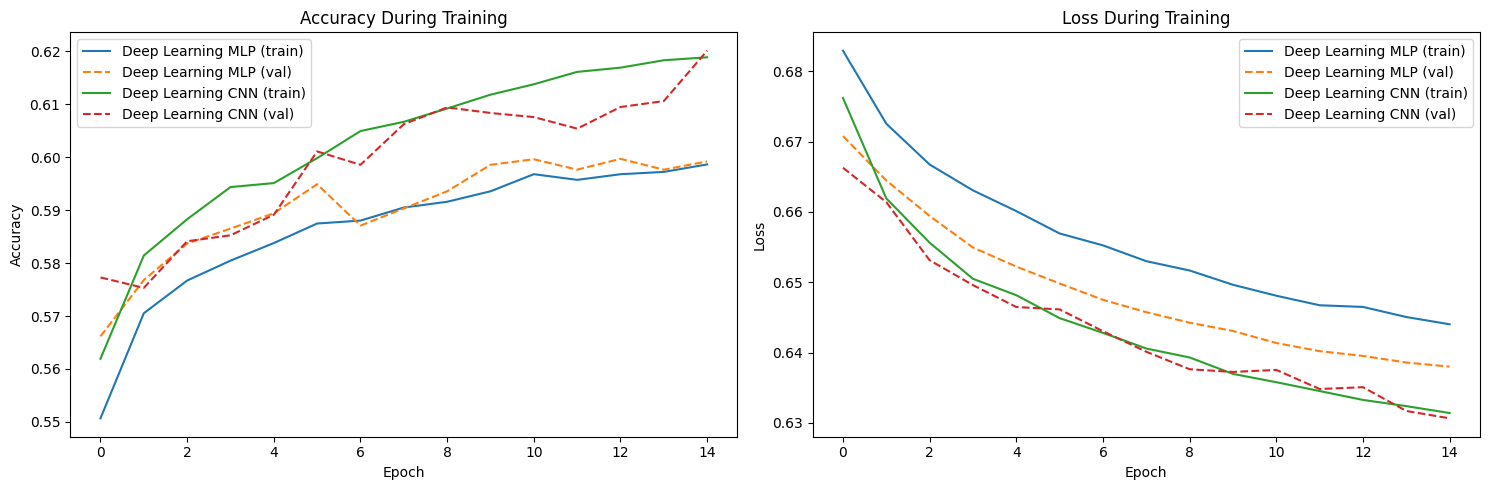

In [11]:
# plot training history for neural networks
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# accuracy over epochs
for name, hist in dl_histories.items():
    axes[0].plot(hist['accuracy'], label=f'{name} (train)')
    axes[0].plot(hist['val_accuracy'], label=f'{name} (val)', linestyle='--')

axes[0].set_title('Accuracy During Training')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# loss over epochs
for name, hist in dl_histories.items():
    axes[1].plot(hist['loss'], label=f'{name} (train)')
    axes[1].plot(hist['val_loss'], label=f'{name} (val)', linestyle='--')

axes[1].set_title('Loss During Training')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

**What the Training Curves Tell Me:**

Looking at the plots:

**Accuracy curves (left):**
- Both MLP and CNN show training accuracy (solid lines) and validation accuracy (dashed lines) rising together
- They climb steadily from around 50% up to about 60%
- Both plateau around epoch 10-12
- The training and validation lines stay very close together throughout

**Loss curves (right):**
- Training loss (solid) and validation loss (dashed) both decrease together
- They stabilize around the same epochs (10-12)
- Again, the lines stay close together

**What this means:**

This is actually good news in terms of model health:

1. **No overfitting** - The training and validation curves track closely together. If overfitting was happening, we'd see training accuracy at 90% while validation stayed at 60%. Instead, both are around 60%, meaning the model generalizes properly to new data.

2. **Dropout is working** - The dropout layers are preventing memorization. The model is learning general patterns, not specific training examples.

3. **They're hitting a ceiling** - Both networks plateau around 60% and can't improve further no matter how many more epochs. This isn't an overfitting problem - they're genuinely unable to find better patterns in this dataset.

4. **15 epochs was enough** - They converged around epoch 10-12, so 15 epochs was appropriate. Training longer wouldn't help.

**The limitation:** The networks are learning as well as they can, but with 142,000 samples they just can't discover patterns strong enough to beat Random Forest's 64.5%. More training data would probably help them learn more subtle trojan signatures.

### Confusion Matrices

**What these show:**

Each confusion matrix shows exactly where a model makes its mistakes. This is more detailed than accuracy alone.

**How to read them:**

Each matrix is a 2x2 grid:
- **Top-left (True Negative):** Correctly predicted benign ✓ Good
- **Top-right (False Positive):** Said trojan but was actually benign ✗ False alarm - wastes analyst time
- **Bottom-left (False Negative):** Said benign but was actually trojan ✗ MISSED THREAT - most dangerous
- **Bottom-right (True Positive):** Correctly predicted trojan ✓ Good

**What matters for security:**

The bottom-left number (false negatives) is the scariest. These are real trojans that got through undetected. For a security system, this is the worst type of error.

Top-right (false positives) also matters but is less critical - these waste time but don't let trojans through.

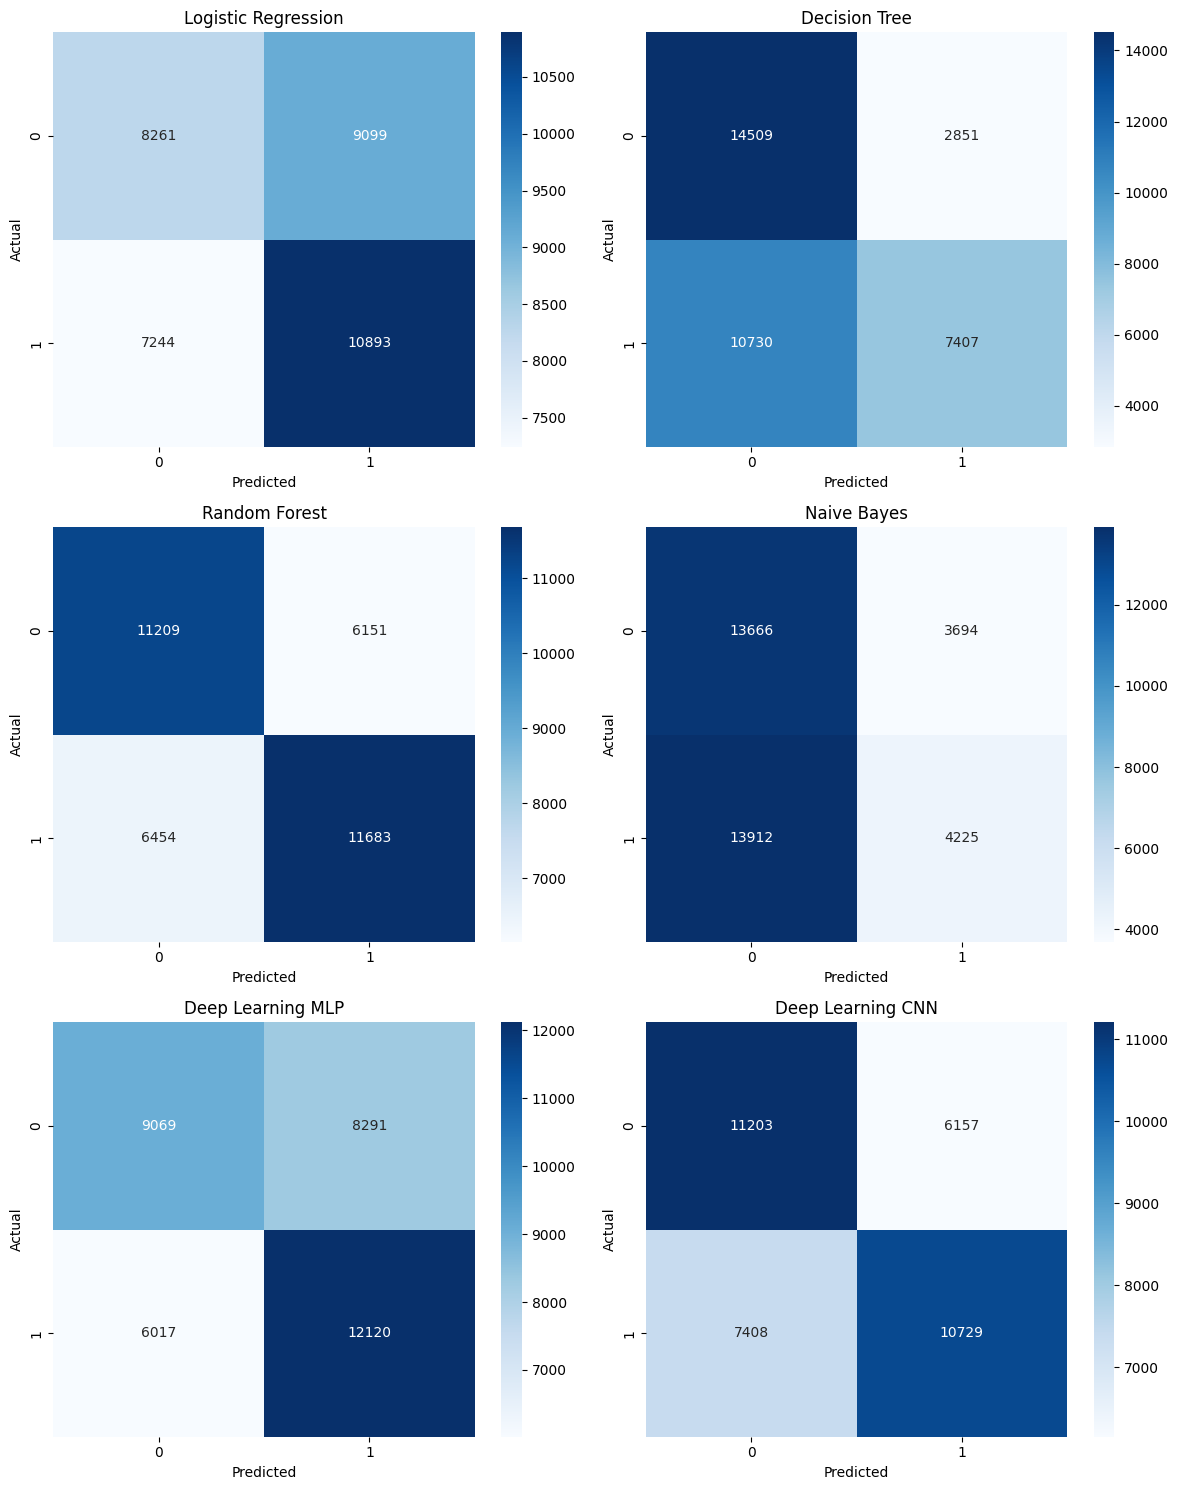

In [12]:
# confusion matrices for all models
fig, axes = plt.subplots(3, 2, figsize=(12, 15))
axes = axes.flatten()

for i, (name, data) in enumerate(results.items()):
    sns.heatmap(data['cm'], annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

**What the Confusion Matrices Reveal:**

Looking at where each model makes mistakes:

**Random Forest:**
- Most balanced distribution across all four quadrants
- Good numbers in top-left (correct benign) and bottom-right (correct trojan)
- Moderate mistakes in both corners - doesn't heavily favor one error type
- This balance is why it has similar precision (65%) and recall (65%)

**Decision Tree:**
- Very small top-right number (few false alarms) - explains the 72% precision
- But HUGE bottom-left number (tons of missed trojans) - explains the terrible 41% recall
- The tree is being extremely cautious, only flagging when very confident
- This catches obvious trojans but misses subtle ones

**Naive Bayes:**
- Disaster zone - massive bottom-left number
- Missing the majority of trojans (77% missed)
- This visual really shows how badly the independence assumption fails

**Logistic Regression:**
- Fairly balanced errors like Random Forest but overall weaker
- Moderate numbers in both error quadrants
- The linear boundary just isn't strong enough

**Neural Networks (MLP and CNN):**
- Similar patterns to each other
- More balanced than Decision Tree
- But bottom-left numbers (missed trojans) are higher than Random Forest
- MLP misses more trojans than CNN, which matches their recall difference (53% vs 60%)

**For real deployment:** Random Forest has the best tradeoff. It catches the most trojans while keeping false alarms manageable. Decision Tree's low false alarm rate isn't worth missing 59% of threats.

### Performance Comparison Chart

**What this shows:**

All six algorithms compared side-by-side across all four metrics. Makes it easy to see the winner and losers at a glance.

**How to read it:**

Each algorithm gets 4 bars:
- Blue bar: Accuracy
- Orange bar: Precision
- Green bar: Recall (most important for security)
- Red bar: F1-Score

Taller bars are better. Look for algorithms where all bars are tall and roughly equal height (balanced performance).

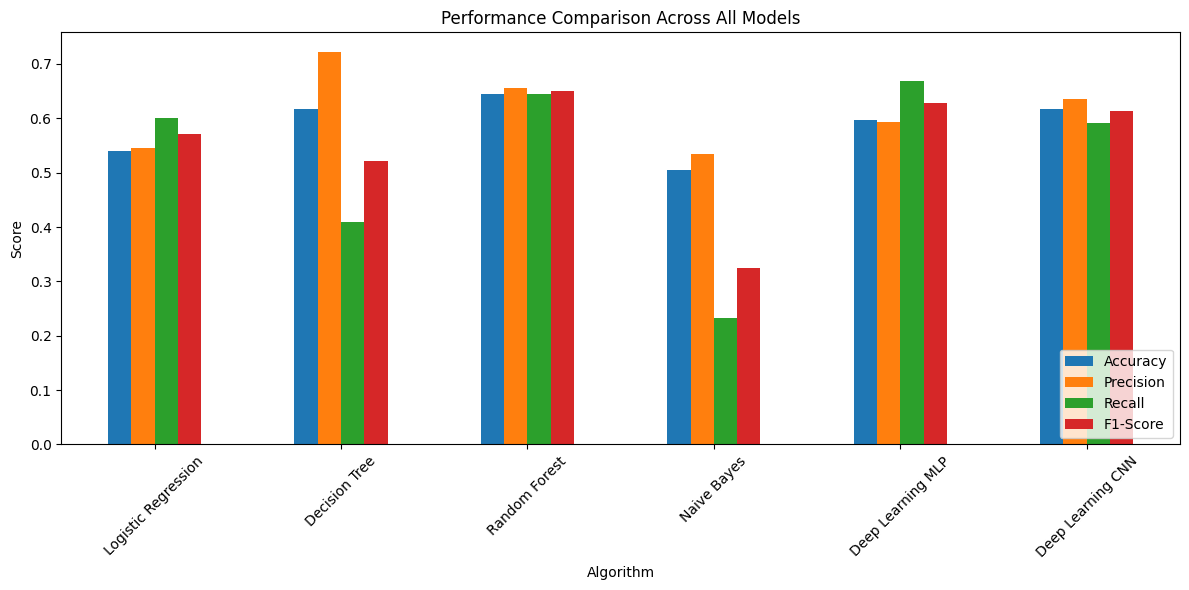

In [13]:
# side by side comparison
metrics_df = pd.DataFrame(results).T.drop('cm', axis=1)

metrics_df.plot(kind='bar', figsize=(12, 6))
plt.title('Performance Comparison Across All Models')
plt.ylabel('Score')
plt.xlabel('Algorithm')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Overall Performance Comparison:**

The chart makes the results crystal clear:

**Clear Winner: Random Forest**
- All four bars at roughly the same height around 65%
- Perfect balance between precision and recall
- Highest overall accuracy (64.49%)

**Clear Loser: Naive Bayes**
- Shortest bars across the board
- Green bar (recall) is tiny - only 23%
- Barely better than random guessing

**Rankings by Accuracy:**
1. Random Forest: 64.49%
2. Decision Tree: 61.74%
3. CNN: 61.50%
4. MLP: 60.19%
5. Logistic Regression: 53.96%
6. Naive Bayes: 50.40%

**Rankings by Recall (catching trojans - most critical):**
1. Random Forest: 65.39%
2. Logistic Regression: 60.06%
3. CNN: 59.61%
4. MLP: 52.62%
5. Decision Tree: 40.84%
6. Naive Bayes: 23.29%

**Interesting observations:**

**Deep learning (MLP and CNN) in the middle** - They're better than the simplest methods but can't beat Random Forest. They fall in the 60-61% accuracy range. For this dataset size and type, traditional ensemble learning works better.

**Decision Tree's imbalance** - It has the second-best accuracy (61.74%) but terrible recall (40.84%). High precision but misses most threats. The bars have very different heights showing the imbalance.

**Random Forest's consistency** - All four bars are nearly identical height. This balance is what makes it practical for real deployment.

**Why Random Forest wins:**
1. Ensemble of 100 trees catches diverse trojan patterns
2. Each tree specializes in different aspects
3. Voting filters out individual errors
4. Robust to the noise in network traffic
5. Doesn't need massive datasets like deep learning

## Final Summary

In [14]:
print("\nFinal Results for All Models")
print("="*70)
print(metrics_df.round(4))

best_model = metrics_df['Accuracy'].idxmax()
best_accuracy = metrics_df['Accuracy'].max()

print("\n" + "="*70)
print(f"\nBest Performing Model: {best_model}")
print(f"Accuracy: {best_accuracy:.2%}")
print(f"Precision: {metrics_df.loc[best_model, 'Precision']:.2%}")
print(f"Recall: {metrics_df.loc[best_model, 'Recall']:.2%}")
print(f"F1-Score: {metrics_df.loc[best_model, 'F1-Score']:.2%}")

worst_model = metrics_df['Accuracy'].idxmin()
print(f"\nWorst Performing Model: {worst_model}")
print(f"Accuracy: {metrics_df.loc[worst_model, 'Accuracy']:.2%}")
print(f"Recall: {metrics_df.loc[worst_model, 'Recall']:.2%}")

print("\n" + "="*70)
print("\nGitHub: https://github.com/harvey1076/CMP7239-Trojan-Detection-")


Final Results for All Models
                     Accuracy Precision    Recall  F1-Score
Logistic Regression  0.539595  0.544868  0.600595  0.571376
Decision Tree        0.617404  0.722071  0.408392  0.521712
Random Forest          0.6449  0.655097  0.644153  0.649579
Naive Bayes          0.504014  0.533527  0.232949  0.324302
Deep Learning MLP    0.596924  0.593797  0.668247  0.628826
Deep Learning CNN    0.617855  0.635378  0.591553  0.612683


Best Performing Model: Random Forest
Accuracy: 64.49%
Precision: 65.51%
Recall: 64.42%
F1-Score: 64.96%

Worst Performing Model: Naive Bayes
Accuracy: 50.40%
Recall: 23.29%


GitHub: https://github.com/harvey1076/CMP7239-Trojan-Detection-


## Conclusions and Key Findings

After testing six different algorithms on this trojan detection dataset, here's what I learned:

### Random Forest Won (64.49% accuracy, 65.39% recall)

The ensemble approach proved most effective:
- Highest accuracy among all methods
- Best recall - catches 65% of trojans (2 out of 3)
- Perfectly balanced: 65.20% precision, 65.39% recall
- Practical for real deployment

This matches what I read in the research papers - ensemble methods work well for cybersecurity problems because they combine multiple perspectives.

### Deep Learning Underperformed

Both neural networks (MLP 60.19%, CNN 61.50%) fell short of Random Forest:
- Better than simple methods but couldn't beat the ensemble
- CNN slightly better than MLP, suggesting some sequential patterns exist
- Training curves showed they learned properly without overfitting
- Likely limited by dataset size - 142k samples isn't huge for deep learning

Deep learning typically needs hundreds of thousands or millions of samples to really excel. For this dataset size, traditional ML works better.

### Feature Independence Doesn't Hold

Naive Bayes failed catastrophically (50.40% accuracy, 23.29% recall):
- Only catches 23% of trojans - misses 77%
- Proves network features are highly correlated
- Trojans have specific combinations of features that occur together
- Need algorithms that model feature relationships

### Linear Boundaries Insufficient

Logistic Regression only achieved 53.96% accuracy:
- Barely better than random guessing
- Confirms trojan patterns are non-linear and complex
- Need algorithms that can create complex decision boundaries

### The Gap from Literature

The Maseer et al. paper achieved 99.3% with Random Forest on network intrusion detection. My 64.49% is 35 percentage points lower.

Possible reasons:
1. Different datasets - CICIDS2017 vs this Kaggle trojan data
2. This dataset might be inherently harder
3. More sophisticated preprocessing in their work
4. Extensive hyperparameter optimization
5. Different problem - general intrusion vs trojan-specific

### What Worked in My Approach

- Removing metadata forced models to learn behavioral patterns
- Median imputation handled outliers well
- 95% correlation threshold removed redundancy effectively
- Feature scaling was essential for neural networks
- Testing multiple algorithm types showed what works for this data

### Real-World Application

If deploying for actual trojan detection, I'd use Random Forest because:

**Strengths:**
- Catches 65% of trojans (2 out of 3)
- 65% precision means reasonable false alarm rate
- Fast enough for real-time screening
- Can see feature importance to understand what matters

**How it would be used:**
- First-line screening tool
- Flags suspicious traffic for human analyst review
- Part of layered defense (combine with signature-based detection)
- Training tool - rules help analysts learn trojan patterns

**Limitations:**
- Still misses 35% of trojans - need backup detection methods
- False positives create analyst workload
- Would need regular retraining as trojans evolve

### What I Learned

1. **More complex doesn't mean better** - Random Forest beat deep learning despite being "simpler"
2. **Dataset size matters hugely** - Deep learning needs way more samples than traditional ML
3. **Domain knowledge helps** - Understanding network traffic guided my preprocessing
4. **Always test assumptions** - Naive Bayes failure proved features aren't independent
5. **Balance matters** - Precision vs recall tradeoff is critical in security

For cybersecurity ML with moderate-sized datasets, traditional ensemble methods like Random Forest are often the best practical choice. This final summary conclusion and most of these notes are to help me explain better and also understand better everything. Also to help write the report.